In [1]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
df=pd.read_csv(r"Downloads\ev_charging_station_dataset.csv")
df.head()
df.info()
df['start_time']=pd.to_datetime(df['start_time'])
df['end_time']=pd.to_datetime(df['end_time'])
df.dropna(inplace=True)
df['duration_minutes']=(df['end_time']-df['start_time']).dt.total_seconds()/60
df['hour']=df['start_time'].dt.hour
df['day']=df['start_time'].dt.day_name()
df['month']=df['start_time'].dt.month
print("Total Revenue",df['cost'].sum())
print("Total Energy Consumption",df['energy_kwh'].sum())
print("Average Charging Duration",df['duration_minutes'].mean())
print("Total Sessions",len(df))



<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station_id    2000 non-null   str    
 1   location      2000 non-null   str    
 2   charger_type  2000 non-null   str    
 3   vehicle_type  2000 non-null   str    
 4   start_time    2000 non-null   str    
 5   end_time      2000 non-null   str    
 6   energy_kwh    2000 non-null   float64
 7   cost          2000 non-null   float64
 8   user_id       2000 non-null   str    
 9   status        2000 non-null   str    
dtypes: float64(2), str(8)
memory usage: 156.4 KB
Total Revenue 2004955.3299999998
Total Energy Consumption 173577.2
Average Charging Duration 123.698
Total Sessions 2000


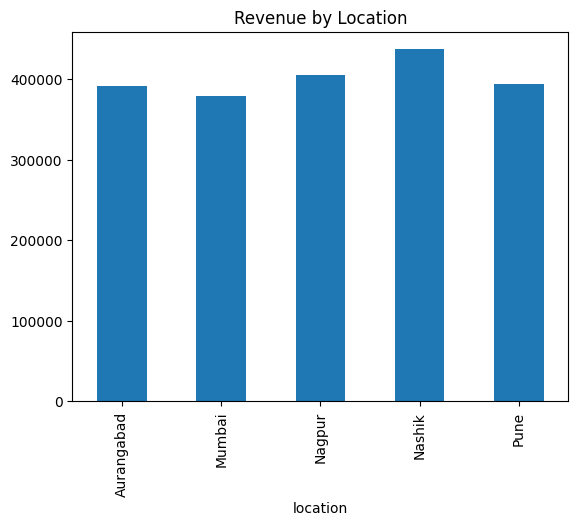

In [2]:
df.groupby('location')['cost'].sum().plot(kind='bar')
plt.title("Revenue by Location")
plt.show()

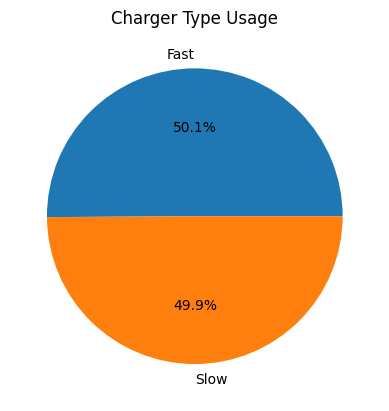

In [3]:
df['charger_type'].value_counts().plot(
kind='pie', autopct='%1.1f%%'
)
plt.title("Charger Type Usage")
plt.show()

In [10]:
station_perf = df.groupby('station_id')['energy_kwh'].sum()
station_perf.sort_values(ascending=False).head(10)

station_id
ST006    10078.8
ST005    10037.6
ST019     9981.7
ST017     9599.0
ST018     9344.4
ST010     9337.8
ST020     9160.0
ST013     8859.3
ST002     8708.0
ST016     8621.8
Name: energy_kwh, dtype: float64

In [11]:
#ye code likhate hi hame home page mein ek file create hoke mili i.e ev_cleaned_data.xlsx use hmne download kiya aur use keiya powerbi mwin
df.to_csv("ev_cleaned_data.csv", index=False)